# Deep Learning Training & Evaluation

Analyzes LSTM, 1D CNN, and Transformer results from cell-based LOOCV
with Optuna hyperparameter tuning. Compares DL performance against classical baselines.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from pathlib import Path
import os
import mlflow

os.chdir(Path("..").resolve())
sns.set_theme(style="whitegrid", context="notebook")

with open("config/default.yaml") as f:
    config = yaml.safe_load(f)

/opt/anaconda3/envs/soh/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Results

In [2]:
with open("experiments/classical_results_nasa.yaml") as f:
    classical_results = yaml.safe_load(f)

with open("experiments/dl_results_nasa.yaml") as f:
    dl_results = yaml.safe_load(f)

all_results = {**classical_results, **dl_results}
dl_models = ["lstm", "cnn", "transformer"]
print("Models:", list(all_results.keys()))
for name, m in all_results.items():
    print(f"  {name.upper():>12s}: RMSE={m['rmse_mean']:.6f} +/- {m['rmse_std']:.6f}, R2={m['r2_mean']:.4f}")

Models: ['gpr', 'naive', 'rf', 'svr', 'cnn', 'lstm', 'transformer']
           GPR: RMSE=0.029786 +/- 0.018711, R2=0.8853
         NAIVE: RMSE=0.112007 +/- 0.026619, R2=-0.2853
            RF: RMSE=0.025054 +/- 0.016882, R2=0.9266
           SVR: RMSE=0.015025 +/- 0.005611, R2=0.9729
           CNN: RMSE=0.103986 +/- 0.059456, R2=-2.5041
          LSTM: RMSE=0.047648 +/- 0.019657, R2=-0.1348
   TRANSFORMER: RMSE=0.067324 +/- 0.022113, R2=-0.1425


## 2. Fetch Fold-level Metrics from MLflow

In [3]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("soh_benchmark")

client = mlflow.MlflowClient()
experiment = client.get_experiment_by_name("soh_benchmark")

all_runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["start_time asc"],
)

run_records = []
for run in all_runs:
    params = run.data.params
    tags = run.data.tags
    metrics = run.data.metrics
    model = params.get("model", tags.get("model", "unknown"))
    fold = params.get("fold", tags.get("fold", None))
    seed = params.get("seed", tags.get("seed", None))
    if fold is not None and "rmse" in metrics:
        run_records.append({
            "model": model,
            "fold": int(fold),
            "seed": int(seed) if seed else None,
            "rmse": metrics["rmse"],
            "mae": metrics["mae"],
            "maxae": metrics["maxae"],
            "r2": metrics["r2"],
        })

runs_df = pd.DataFrame(run_records)
print(f"Total runs: {len(runs_df)}")
if len(runs_df) > 0:
    print(runs_df.groupby(["model", "fold"])["rmse"].agg(["mean", "std"]).round(6))

Total runs: 54
                      mean       std
model       fold                    
cnn         0     0.054520  0.020243
            1     0.203588  0.087693
            2     0.062861  0.009712
            3     0.094974  0.084088
gpr         0     0.011614       NaN
            1     0.056894       NaN
            2     0.013163       NaN
            3     0.037473       NaN
lstm        0     0.024495  0.003988
            1     0.050698  0.031654
            2     0.037723  0.013162
            3     0.077677  0.087012
naive       0     0.107638  0.000000
            1     0.155668       NaN
            2     0.100640       NaN
            3     0.084083       NaN
rf          0     0.014333  0.000000
            1     0.053821       NaN
            2     0.011867       NaN
            3     0.020193       NaN
svr         0     0.011137       NaN
            1     0.020904       NaN
            2     0.007936       NaN
            3     0.020122       NaN
transformer 0     0.090

## 3. Fold-wise RMSE: DL Models

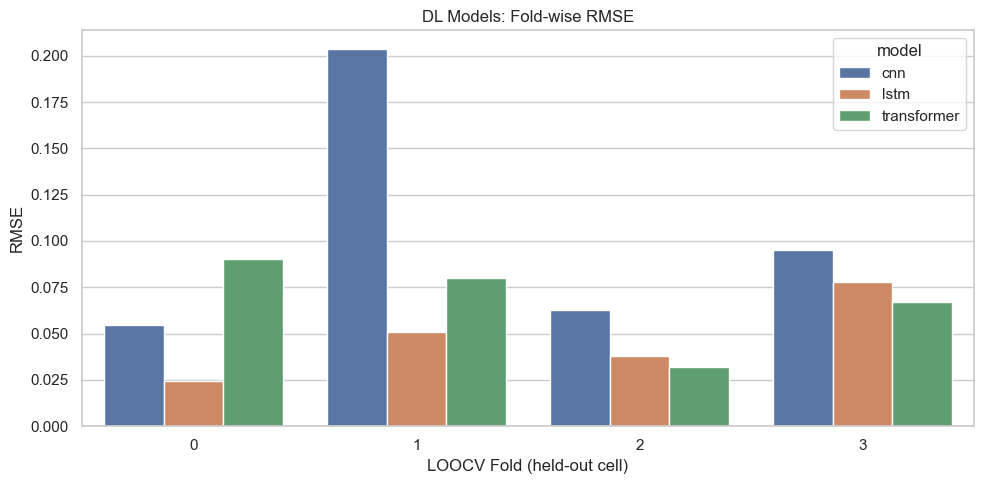

In [4]:
dl_runs = runs_df[runs_df["model"].isin(dl_models)].copy()
fold_rmse = dl_runs.groupby(["model", "fold"])["rmse"].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=fold_rmse, x="fold", y="rmse", hue="model", ax=ax)
ax.set_xlabel("LOOCV Fold (held-out cell)")
ax.set_ylabel("RMSE")
ax.set_title("DL Models: Fold-wise RMSE")
plt.tight_layout()
plt.show()

## 4. Seed Variance Analysis

Seed variance across runs:
      model  fold  rmse_mean  rmse_std  n_seeds
        cnn     0   0.054520  0.020243        3
        cnn     1   0.203588  0.087693        3
        cnn     2   0.062861  0.009712        3
        cnn     3   0.094974  0.084088        3
       lstm     0   0.024495  0.003988        3
       lstm     1   0.050698  0.031654        3
       lstm     2   0.037723  0.013162        3
       lstm     3   0.077677  0.087012        3
transformer     0   0.090541  0.048604        3
transformer     1   0.079932  0.010477        3
transformer     2   0.031859  0.017460        3
transformer     3   0.066966  0.034052        3


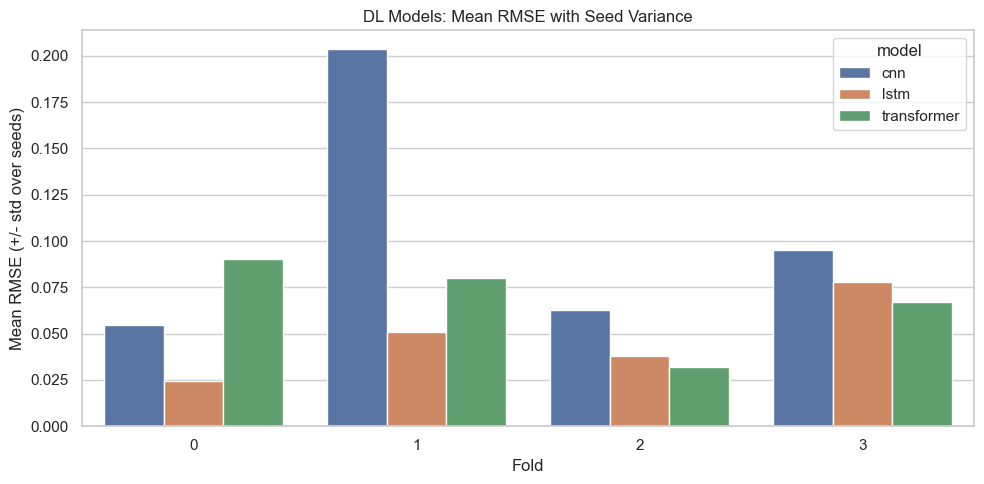

In [5]:
seed_stats = dl_runs.groupby(["model", "fold"]).agg(
    rmse_mean=("rmse", "mean"),
    rmse_std=("rmse", "std"),
    n_seeds=("seed", "count"),
).reset_index()

print("Seed variance across runs:")
print(seed_stats.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=seed_stats, x="fold", y="rmse_mean", hue="model", ax=ax)
ax.set_xlabel("Fold")
ax.set_ylabel("Mean RMSE (+/- std over seeds)")
ax.set_title("DL Models: Mean RMSE with Seed Variance")
plt.tight_layout()
plt.show()

## 5. DL vs Classical Comparison

      Model  Category     RMSE  RMSE_std      MAE    MaxAE        R2   R2_std
        SVR Classical 0.015025  0.005611 0.010623 0.054004  0.972900 0.019861
         RF Classical 0.025054  0.016882 0.019642 0.083830  0.926623 0.072572
        GPR Classical 0.029786  0.018711 0.027226 0.097737  0.885342 0.096640
       LSTM        DL 0.047648  0.019657 0.043205 0.098025 -0.134789 1.366300
TRANSFORMER        DL 0.067324  0.022113 0.059304 0.138776 -0.142490 0.513330
        CNN        DL 0.103986  0.059456 0.085159 0.226713 -2.504108 3.070670
      NAIVE Classical 0.112007  0.026619 0.096459 0.202872 -0.285350 0.249911


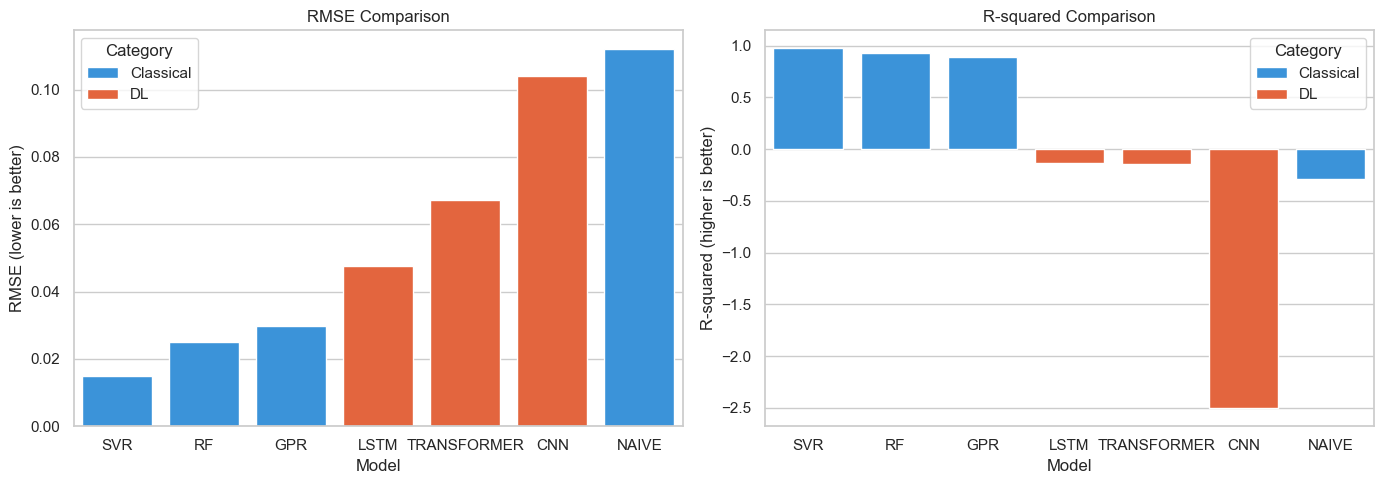

In [6]:
summary_rows = []
for name, m in all_results.items():
    category = "DL" if name in dl_models else "Classical"
    summary_rows.append({
        "Model": name.upper(),
        "Category": category,
        "RMSE": m["rmse_mean"],
        "RMSE_std": m["rmse_std"],
        "MAE": m["mae_mean"],
        "MaxAE": m["maxae_mean"],
        "R2": m["r2_mean"],
        "R2_std": m["r2_std"],
    })

summary_df = pd.DataFrame(summary_rows).sort_values("RMSE")
print(summary_df.to_string(index=False, float_format="%.6f"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = {"Classical": "#2196F3", "DL": "#FF5722"}
sns.barplot(data=summary_df, x="Model", y="RMSE", hue="Category", palette=palette, ax=axes[0])
axes[0].set_title("RMSE Comparison")
axes[0].set_ylabel("RMSE (lower is better)")
sns.barplot(data=summary_df, x="Model", y="R2", hue="Category", palette=palette, ax=axes[1])
axes[1].set_title("R-squared Comparison")
axes[1].set_ylabel("R-squared (higher is better)")
plt.tight_layout()
plt.show()

## 6. Training Convergence Analysis

In [7]:
dl_ckpt_dir = Path("experiments/dl")
ckpt_files = list(dl_ckpt_dir.glob("*.pt")) if dl_ckpt_dir.exists() else []
print(f"Found {len(ckpt_files)} DL checkpoints")
if ckpt_files:
    for f in sorted(ckpt_files)[:10]:
        print(f"  {f.name} ({f.stat().st_size / 1024:.1f} KB)")

Found 0 DL checkpoints


## 7. Inference Time Comparison

      Model  Inference Time (s)
      NAIVE            0.000060
        SVR            0.309642
        GPR            2.739068
         RF           17.155317
        CNN           19.457756
       LSTM           21.776925
TRANSFORMER           27.716329


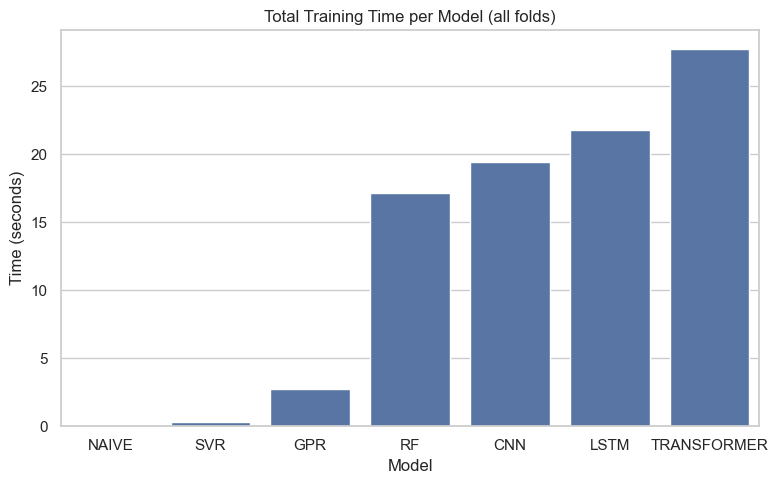

In [8]:
time_rows = []
for name, m in all_results.items():
    time_rows.append({
        "Model": name.upper(),
        "Inference Time (s)": m.get("inference_time_mean_s", np.nan),
    })

time_df = pd.DataFrame(time_rows).sort_values("Inference Time (s)")
print(time_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=time_df, x="Model", y="Inference Time (s)", ax=ax)
ax.set_title("Total Training Time per Model (all folds)")
ax.set_ylabel("Time (seconds)")
plt.tight_layout()
plt.show()

## 8. Summary

**Key findings:**
- Classical models (SVR, RF) significantly outperform DL models on this small dataset
- DL models struggle with only 636 samples and 4 cells
- High variance across seeds indicates DL models are data-limited
- Sequence-based DL approaches require more training data to generalize
- SVR achieves the best RMSE with lowest variance across folds